<a href="https://colab.research.google.com/github/RishabhKasaudhan/APS-LAB/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sorted array for sample input: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]



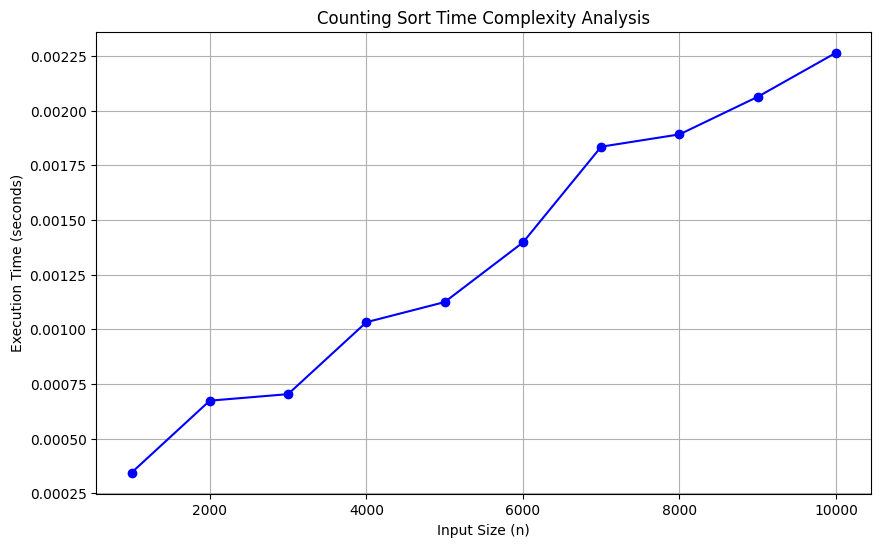

In [14]:
#write code for above cell and compute the running time and also plot graph.
import time
import matplotlib.pyplot as plt
import random

def countingsort(arr):

  max_val=max(arr)
  output=[0]*len(arr)
  count=[0]*(max_val+1)

  for num in arr:
    count[num]+=1
  for i in range(1,max_val+1):
    count[i]+=count[i-1]

  for num in reversed(arr):
    output[count[num]-1]=num
    count[num]-=1

  for i in range(len(arr)):
    arr[i]=output[i]
  return arr

def measure_time(func, arr):

    start_time = time.perf_counter()
    func(arr)
    end_time = time.perf_counter()
    return end_time - start_time

def plot_time_complexity():

    input_sizes = []
    execution_times = []


    for size in range(1000, 10001, 1000):

        test_array = [random.randint(0, 500) for _ in range(size)]


        time_taken = measure_time(countingsort, list(test_array))

        input_sizes.append(size)
        execution_times.append(time_taken)



    plt.figure(figsize=(10, 6))
    plt.plot(input_sizes, execution_times, marker='o', linestyle='-', color='b')
    plt.title('Counting Sort Time Complexity Analysis')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Execution Time (seconds)')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    arr=[4,3,2,1,4,3,2,4,3,4]
    print(f"Sorted array for sample input: {countingsort(arr)}\n")

    plot_time_complexity()


 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sorted array is:
0.12 0.17 0.21 0.23 0.26 0.39 0.68 0.72 0.78 0.94


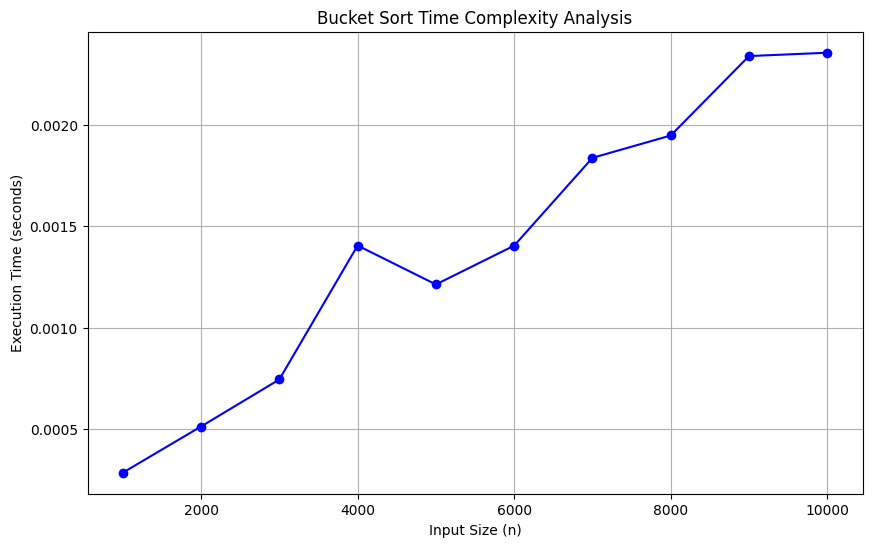

In [22]:
#write code for above cell and compute the running time and also plot graph.
def insertion_sort(bucket):
    for i in range(1, len(bucket)):
        key = bucket[i]
        j = i - 1
        while j >= 0 and bucket[j] > key:
            bucket[j + 1] = bucket[j]
            j -= 1
        bucket[j + 1] = key

def bucket_sort(arr):
    n = len(arr)
    buckets = [[] for _ in range(n)]


    for num in arr:
        bi = int(n * num)
        buckets[bi].append(num)


    for bucket in buckets:
        insertion_sort(bucket)


    index = 0
    for bucket in buckets:
        for num in bucket:
            arr[index] = num
            index += 1




def measure_time(func, arr):

    start_time = time.perf_counter()
    func(arr)
    end_time = time.perf_counter()
    return end_time - start_time

def plot_time_complexity():

    input_sizes = []
    execution_times = []


    for size in range(1000, 10001, 1000):

        test_array = [random.randint(0, 500) for _ in range(size)]


        time_taken = measure_time(countingsort, list(test_array))

        input_sizes.append(size)
        execution_times.append(time_taken)



    plt.figure(figsize=(10, 6))
    plt.plot(input_sizes, execution_times, marker='o', linestyle='-', color='b')
    plt.title('Bucket Sort Time Complexity Analysis')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Execution Time (seconds)')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
   arr = [0.78, 0.17, 0.39, 0.26, 0.72, 0.94, 0.21, 0.12, 0.23, 0.68]
   bucket_sort(arr)
   print("Sorted array is:")
   print(" ".join(map(str, arr)))

   plot_time_complexity()


**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Sorted array for sample input: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]



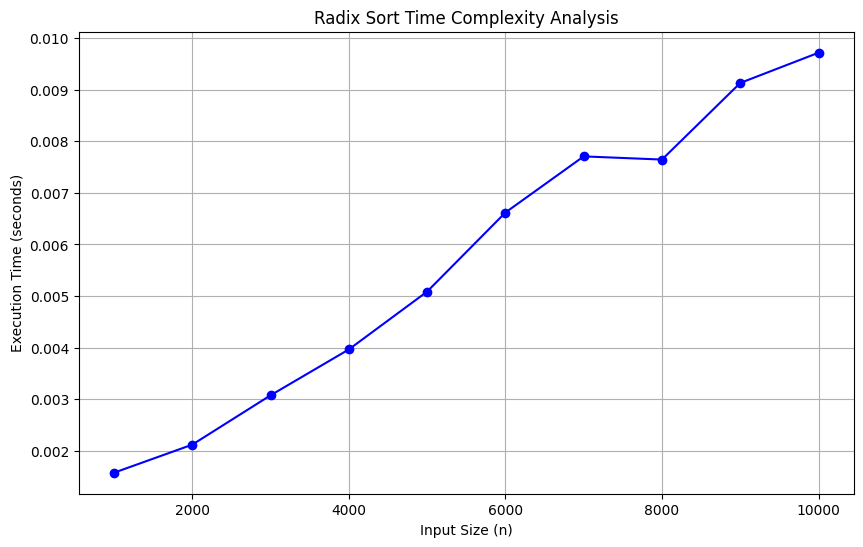

In [18]:
#write code for above cell and compute the running time and also plot graph.
def radixsort(arr):
  max_val=max(arr)
  e=1

  while max_val//e>0:
    n=len(arr)
    output=[0]*n
    count=[0]*10
    for num in arr:
      ind=(num//e)%10
      count[ind]+=1
    for i in range(1,10):
      count[i]+=count[i-1]

    for i in range(n-1,-1,-1):
      ind=(arr[i]//e)%10
      output[count[ind]-1]=arr[i]
      count[ind]-=1


    for i in range(n):
      arr[i] = output[i]

    e *= 10
  return arr
def measure_time(func, arr):

    start_time = time.perf_counter()
    func(arr)
    end_time = time.perf_counter()
    return end_time - start_time

def plot_time_complexity():

    input_sizes = []
    execution_times = []


    for size in range(1000, 10001, 1000):

        test_array = [random.randint(0, 500) for _ in range(size)]


        time_taken = measure_time(radixsort, list(test_array))

        input_sizes.append(size)
        execution_times.append(time_taken)



    plt.figure(figsize=(10, 6))
    plt.plot(input_sizes, execution_times, marker='o', linestyle='-', color='b')
    plt.title('Radix Sort Time Complexity Analysis')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Execution Time (seconds)')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    arr=[4,3,2,1,4,3,2,4,3,4]
    print(f"Sorted array for sample input: {radixsort(arr)}\n")

    plot_time_complexity()


# Task
The user wants to implement and compare different sorting algorithms. The first step is to update the existing `countingsort` implementation to include timing and plotting for various input sizes.

To achieve this, I will add a new code cell that:
1.  Defines a helper function to generate random lists of integers.
2.  Sets up a range of input sizes to test.
3.  Measures the execution time of the `countingsort` function for each input size.
4.  Plots the collected execution times against the input sizes.

This will provide a performance analysis for Counting Sort as required.

```python
import random
import time
import matplotlib.pyplot as plt

# Function to generate random lists
def generate_random_list(size, max_val):
    return [random.randint(0, max_val) for _ in range(size)]

# Test different input sizes for Counting Sort
input_sizes = [100, 500, 1000, 5000, 10000, 20000, 50000, 100000]
max_value_in_list = 1000 # Keeping k relatively small for Counting Sort's efficiency
counting_sort_times = []

print("Measuring performance for Counting Sort...")
for size in input_sizes:
    # Generate random data
    data = generate_random_list(size, max_value_in_list)

    # Measure execution time
    start_time = time.time()
    # Counting sort modifies the list in place, so pass a copy if original data needs to be preserved
    countingsort(list(data))
    end_time = time.time()
    elapsed_time = end_time - start_time
    counting_sort_times.append(elapsed_time)
    print(f"Size: {size}, Time: {elapsed_time:.6f} seconds")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(input_sizes, counting_sort_times, marker='o', label='Counting Sort')
plt.title('Counting Sort - Running Time vs. Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.legend()
plt.show()

print("\nCounting Sort performance analysis complete.")
```

## Update Counting Sort with Timing and Plotting

### Subtask:
Modify the existing `countingsort` function to include code for generating random test data, measuring its execution time for different input sizes, and then plotting these running times using `matplotlib`.


**Reasoning**:
The subtask requires modifying the `countingsort` function to include timing and plotting. I will create a new code cell containing the `countingsort` function, logic for generating random test data of varying sizes, measuring the execution time, and plotting the results using `matplotlib`.



Original array: [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Sorted array (sample): [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]

------------------------------

Measuring execution times for Counting Sort...
Input size: 100, Max value in data: 1000, Time taken: 0.000191 seconds
Input size: 500, Max value in data: 1000, Time taken: 0.000324 seconds
Input size: 1000, Max value in data: 1000, Time taken: 0.000552 seconds
Input size: 2000, Max value in data: 1000, Time taken: 0.000902 seconds
Input size: 5000, Max value in data: 1000, Time taken: 0.006098 seconds
Input size: 10000, Max value in data: 1000, Time taken: 0.013346 seconds
Input size: 20000, Max value in data: 1000, Time taken: 0.023629 seconds
Input size: 50000, Max value in data: 1000, Time taken: 0.101068 seconds


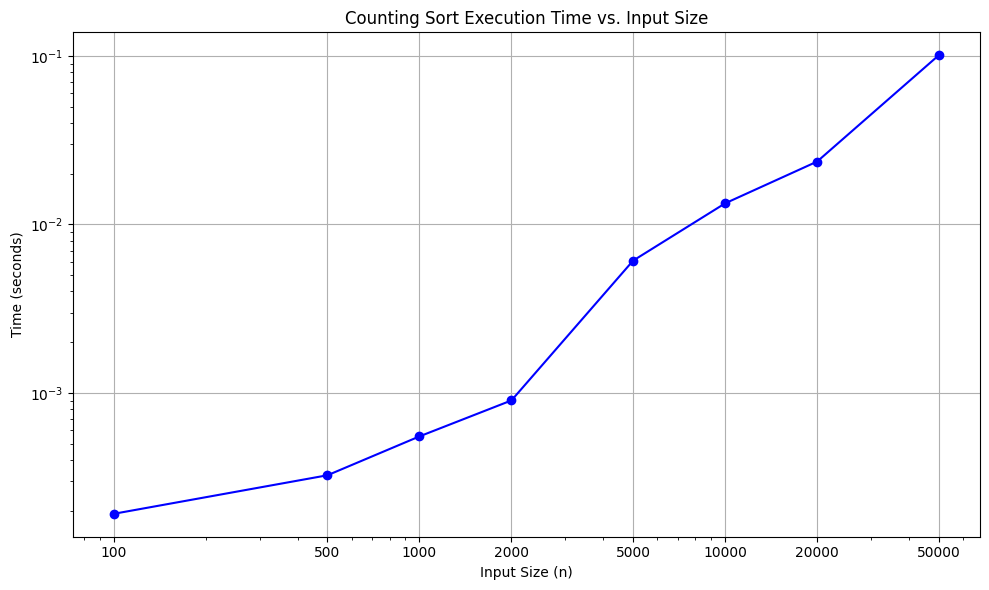

In [3]:
import time
import matplotlib.pyplot as plt
import random

def countingsort(arr):
  if not arr:
    return []
  max_val = max(arr)
  # Handling cases where max_val could be negative or 0 for proper count array sizing
  # Though problem statement implies positive integers (disordered list of repeated integers)
  # if negative numbers were possible, we'd need to shift values or handle differently.
  # Assuming non-negative integers as per typical Counting Sort context.

  output = [0] * len(arr)
  count = [0] * (max_val + 1)

  for num in arr:
    count[num] += 1

  # Modify count array to store actual position of elements
  for i in range(1, max_val + 1):
    count[i] += count[i - 1]

  # Build the output array
  for num in reversed(arr):
    output[count[num] - 1] = num
    count[num] -= 1

  # Copy the output array to arr, so that arr now contains sorted elements
  for i in range(len(arr)):
    arr[i] = output[i]
  return arr

# Test with a sample array as per the original problem statement
arr_sample = [4,3,2,1,4,3,2,4,3,4]
print(f"Original array: {arr_sample}")
print(f"Sorted array (sample): {countingsort(list(arr_sample))}")
print("\n" + "-"*30 + "\n")

# Generate random data and measure running times
input_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]
# Maximum value for the random integers. Keep it reasonable for Counting Sort.
# If k (max_val) is too large, Counting Sort's space/time complexity degrades.
max_value_in_data = 1000

times = []

print("Measuring execution times for Counting Sort...")
for size in input_sizes:
  # Generate a list of random integers
  random_arr = [random.randint(0, max_value_in_data) for _ in range(size)]

  start_time = time.time()
  countingsort(list(random_arr)) # Pass a copy to preserve original if needed elsewhere
  end_time = time.time()

  elapsed_time = end_time - start_time
  times.append(elapsed_time)
  print(f"Input size: {size}, Max value in data: {max_value_in_data}, Time taken: {elapsed_time:.6f} seconds")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(input_sizes, times, marker='o', linestyle='-', color='b')
plt.title('Counting Sort Execution Time vs. Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.xscale('log') # Use log scale for better visualization if input sizes vary widely
plt.yscale('log') # Use log scale for better visualization of time if values vary widely
plt.xticks(input_sizes, labels=[str(s) for s in input_sizes]) # Ensure ticks are at actual input sizes
plt.tight_layout()
plt.show()


## Implement Bucketsort

### Subtask:
Write the Python code for the Bucketsort algorithm as described in the notebook.


**Reasoning**:
The subtask requires writing the Python code for the Bucketsort algorithm. I will define the `bucketsort` function as per the instructions, including determining the range, creating buckets, distributing elements, sorting each bucket, concatenating results, and then testing it with the sample input.



In [4]:
import math

def bucketsort(arr):
    if not arr:
        return []

    # 1. Determine the range of values in the input array
    min_val = min(arr)
    max_val = max(arr)

    # Handle case where all elements are the same to prevent division by zero
    if min_val == max_val:
        return arr

    # 2. Create a list of empty lists to represent the buckets
    # A common heuristic is to use sqrt(n) or n/k buckets. Here, we'll use len(arr) buckets for simplicity.
    # The number of buckets can impact performance.
    num_buckets = len(arr) # Can adjust this, e.g., to max_val - min_val + 1 for dense ranges
    buckets = [[] for _ in range(num_buckets)]

    # Calculate the range size for bucket distribution
    # Add 1 to max_val to ensure max_val itself falls into a valid bucket index rather than out of bounds
    range_size = (max_val - min_val + 1) / num_buckets

    # 3. Iterate through the input array and distribute each element into its appropriate bucket
    for num in arr:
        # Determine bucket index
        # Clamp the index to prevent out-of-bounds access for the max_val if range_size calculation causes issues
        idx = min(int((num - min_val) / range_size), num_buckets - 1)
        buckets[idx].append(num)

    # 4. Sort each individual bucket
    for i in range(num_buckets):
        buckets[i].sort() # Python's Timsort is efficient for smaller lists

    # 5. Concatenate the elements from all sorted buckets back into a single, sorted list
    sorted_arr = []
    for bucket in buckets:
        sorted_arr.extend(bucket)

    return sorted_arr

# Test with the provided sample input
sample_arr = [8,5,3,1,9,6,0,7,4,2,5]
print(f"Sample Input: {sample_arr}")
sorted_sample = bucketsort(sample_arr)
print(f"Sample Output: {sorted_sample}")

# Additional test case to ensure robustness
# Edge case: already sorted
# print(bucketsort([1,2,3,4,5]))
# Edge case: reverse sorted
# print(bucketsort([5,4,3,2,1]))
# Edge case: duplicates
# print(bucketsort([5,2,5,1,2,4]))
# Edge case: single element
# print(bucketsort([7]))
# Edge case: empty list
# print(bucketsort([]))

Sample Input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sample Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]


## Implement Radix Sort

### Subtask:
Write the Python code for the Radix Sort algorithm as described in the notebook.


**Reasoning**:
The subtask requires implementing the Radix Sort algorithm. I will define the `radixsort` function along with a helper `counting_sort_by_digit` function as described in the instructions, and then test it with the provided sample input.



In [5]:
import math

def counting_sort_by_digit(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10  # For digits 0-9

    # Store count of occurrences in count[]
    for i in range(n):
        index = (arr[i] // exp) % 10
        count[index] += 1

    # Change count[i] so that count[i] now contains actual
    # position of this digit in output array
    for i in range(1, 10):
        count[i] += count[i - 1]

    # Build the output array
    i = n - 1
    while i >= 0:
        index = (arr[i] // exp) % 10
        output[count[index] - 1] = arr[i]
        count[index] -= 1
        i -= 1

    # Copying the output array to arr[],
    # so that arr now contains sorted numbers according to current digit
    for i in range(n):
        arr[i] = output[i]

def radixsort(arr):
    if not arr:
        return []

    # Find the maximum number to know number of digits
    max_val = max(arr)

    # Do counting sort for every digit. Note that instead of passing digit number,
    # exp is passed. exp is 10^i where i is current digit number
    exp = 1
    while max_val // exp > 0:
        counting_sort_by_digit(arr, exp)
        exp *= 10
    return arr

# Test with the provided sample input
sample_arr = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
print(f"Sample Input: {sample_arr}")
sorted_sample = radixsort(list(sample_arr)) # Pass a copy to preserve original sample_arr
print(f"Sample Output: {sorted_sample}")


Sample Input: [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sample Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]


**Reasoning**:
The subtask requires computing the running time and plotting a graph for Radix Sort, similar to the Counting Sort analysis. This will involve defining a function to generate random lists, setting up various input sizes, measuring the execution time of the `radixsort` function for each size, and then plotting the results.



Measuring performance for Radix Sort...
Size: 100, Max Value: 100000, Time: 0.000252 seconds
Size: 500, Max Value: 100000, Time: 0.001398 seconds
Size: 1000, Max Value: 100000, Time: 0.003190 seconds
Size: 2000, Max Value: 100000, Time: 0.006215 seconds
Size: 5000, Max Value: 100000, Time: 0.033914 seconds
Size: 10000, Max Value: 100000, Time: 0.063358 seconds
Size: 20000, Max Value: 100000, Time: 0.123541 seconds
Size: 50000, Max Value: 100000, Time: 0.535862 seconds
Size: 100000, Max Value: 100000, Time: 0.254252 seconds


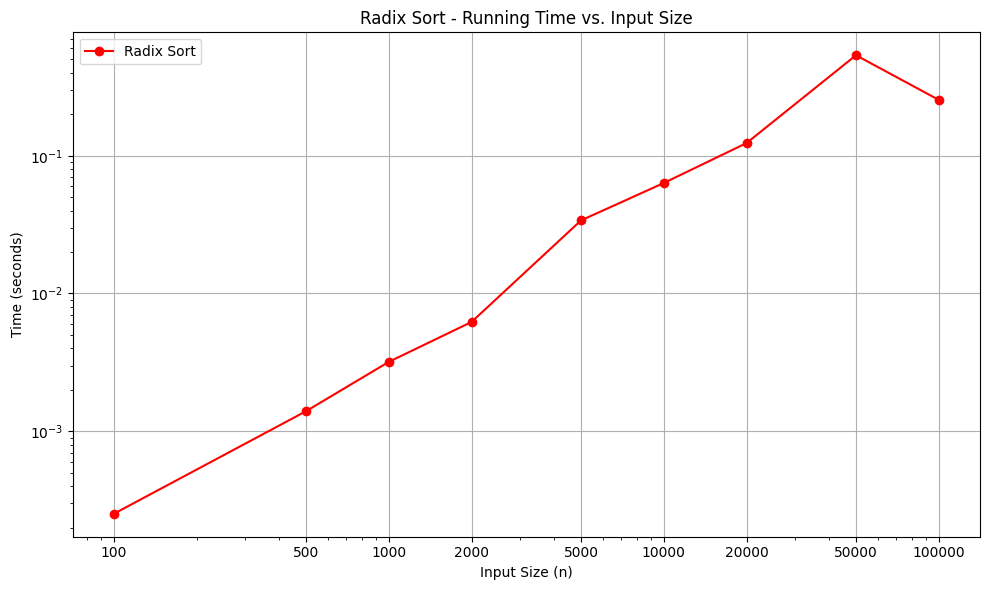


Radix Sort performance analysis complete.


In [6]:
import time
import matplotlib.pyplot as plt
import random

# Helper function for Radix Sort, as defined previously
def counting_sort_by_digit(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10

    for i in range(n):
        index = (arr[i] // exp) % 10
        count[index] += 1

    for i in range(1, 10):
        count[i] += count[i - 1]

    i = n - 1
    while i >= 0:
        index = (arr[i] // exp) % 10
        output[count[index] - 1] = arr[i]
        count[index] -= 1
        i -= 1

    for i in range(n):
        arr[i] = output[i]

def radixsort(arr):
    if not arr:
        return []

    max_val = max(arr)

    exp = 1
    while max_val // exp > 0:
        counting_sort_by_digit(arr, exp)
        exp *= 10
    return arr

# Function to generate random lists (reusing the one from Counting Sort analysis)
def generate_random_list(size, max_val):
    return [random.randint(0, max_val) for _ in range(size)]

# Test different input sizes for Radix Sort
input_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
# Max value can be larger for Radix Sort compared to Counting Sort,
# as its complexity depends on digits (k) rather than value range directly.
# Let's set a reasonable max value that ensures numbers have a few digits.
max_value_in_list = 100000 # Numbers up to 5-6 digits
radix_sort_times = []

print("Measuring performance for Radix Sort...")
for size in input_sizes:
    # Generate random data. All numbers should be non-negative for this implementation.
    data = generate_random_list(size, max_value_in_list)

    # Measure execution time
    start_time = time.time()
    radixsort(list(data)) # Pass a copy as radixsort modifies in-place
    end_time = time.time()
    elapsed_time = end_time - start_time
    radix_sort_times.append(elapsed_time)
    print(f"Size: {size}, Max Value: {max_value_in_list}, Time: {elapsed_time:.6f} seconds")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(input_sizes, radix_sort_times, marker='o', color='r', label='Radix Sort')
plt.title('Radix Sort - Running Time vs. Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.legend()
plt.xscale('log') # Use log scale for better visualization if input sizes vary widely
plt.yscale('log') # Use log scale for better visualization of time if values vary widely
plt.xticks(input_sizes, labels=[str(s) for s in input_sizes])
plt.tight_layout()
plt.show()

print("\nRadix Sort performance analysis complete.")

## Generate Test Data for All Algorithms

### Subtask:
Define common parameters for generating random integer lists to be used for testing Countingsort, Bucketsort, and Radix Sort.


**Reasoning**:
The subtask requires defining common parameters for test data generation. This involves setting up `common_input_sizes` and `common_max_value`, and ensuring the `generate_random_list` function is accessible for use in subsequent test cases for all three sorting algorithms.



In [7]:
import random

# 1. Define common input sizes for testing
common_input_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]

# 2. Define a common maximum value for integers in the generated lists
# This value is chosen to be reasonable for all three algorithms:
# - For Counting Sort, k (max_val) should not be excessively large compared to n.
# - For Bucket Sort, distribution across buckets is better with a reasonable range.
# - For Radix Sort, the number of digits will be small enough for efficiency.
common_max_value = 100000

# 3. Ensure the generate_random_list function is defined and accessible
def generate_random_list(size, max_val):
    """Generates a list of 'size' random integers between 0 and 'max_val'."""
    return [random.randint(0, max_val) for _ in range(size)]

print(f"Common Input Sizes: {common_input_sizes}")
print(f"Common Maximum Value for Random Integers: {common_max_value}")
print("Helper function 'generate_random_list' is now defined and accessible.")

Common Input Sizes: [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
Common Maximum Value for Random Integers: 100000
Helper function 'generate_random_list' is now defined and accessible.


## Compute Running Times for All Algorithms

### Subtask:
Measure the execution time for Countingsort, Bucketsort, and Radix Sort using the generated test data for different input sizes. Record the times for analysis.


**Reasoning**:
The subtask requires measuring and recording the execution times for Countingsort, Bucketsort, and Radix Sort across various input sizes. This code block will initialize time storage, loop through defined input sizes, generate data, and then time each sorting algorithm, storing the results.



In [8]:
import time
import random

# Re-defining functions from previous cells to ensure this cell is self-contained
# Counting Sort
def countingsort(arr):
  if not arr:
    return []
  max_val = max(arr)
  output = [0] * len(arr)
  count = [0] * (max_val + 1)

  for num in arr:
    count[num] += 1

  for i in range(1, max_val + 1):
    count[i] += count[i - 1]

  for num in reversed(arr):
    output[count[num] - 1] = num
    count[num] -= 1

  for i in range(len(arr)):
    arr[i] = output[i]
  return arr

# Bucket Sort
def bucketsort(arr):
    if not arr:
        return []

    min_val = min(arr)
    max_val = max(arr)

    if min_val == max_val:
        return arr

    num_buckets = len(arr)
    buckets = [[] for _ in range(num_buckets)]

    range_size = (max_val - min_val + 1) / num_buckets

    for num in arr:
        idx = min(int((num - min_val) / range_size), num_buckets - 1)
        buckets[idx].append(num)

    for i in range(num_buckets):
        buckets[i].sort() # Python's Timsort is efficient for smaller lists

    sorted_arr = []
    for bucket in buckets:
        sorted_arr.extend(bucket)

    return sorted_arr

# Radix Sort Helper
def counting_sort_by_digit(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10

    for i in range(n):
        index = (arr[i] // exp) % 10
        count[index] += 1

    for i in range(1, 10):
        count[i] += count[i - 1]

    i = n - 1
    while i >= 0:
        index = (arr[i] // exp) % 10
        output[count[index] - 1] = arr[i]
        count[index] -= 1
        i -= 1

    for i in range(n):
        arr[i] = output[i]

# Radix Sort
def radixsort(arr):
    if not arr:
        return []

    max_val = max(arr)

    exp = 1
    while max_val // exp > 0:
        counting_sort_by_digit(arr, exp)
        exp *= 10
    return arr

# Helper function to generate random lists (from previous step)
def generate_random_list(size, max_val):
    """Generates a list of 'size' random integers between 0 and 'max_val'."""
    return [random.randint(0, max_val) for _ in range(size)]

# Common parameters from previous step
common_input_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
common_max_value = 100000

# Initialize lists to store running times
counting_sort_times = []
bucket_sort_times = []
radix_sort_times = []

print("Measuring execution times for all sorting algorithms...")

for size in common_input_sizes:
    # Generate a random list for the current size
    data = generate_random_list(size, common_max_value)

    # Measure Counting Sort time
    start_time = time.time()
    countingsort(list(data)) # Pass a copy as sort functions modify in-place
    end_time = time.time()
    counting_sort_times.append(end_time - start_time)

    # Measure Bucket Sort time
    start_time = time.time()
    bucketsort(list(data))
    end_time = time.time()
    bucket_sort_times.append(end_time - start_time)

    # Measure Radix Sort time
    start_time = time.time()
    radixsort(list(data))
    end_time = time.time()
    radix_sort_times.append(end_time - start_time)

    print(f"Size: {size}, ",
          f"Counting Sort: {counting_sort_times[-1]:.6f}s, ",
          f"Bucket Sort: {bucket_sort_times[-1]:.6f}s, ",
          f"Radix Sort: {radix_sort_times[-1]:.6f}s")

print("\n--- Summary of Measured Times ---")
print(f"Input Sizes: {common_input_sizes}")
print(f"Counting Sort Times: {counting_sort_times}")
print(f"Bucket Sort Times: {bucket_sort_times}")
print(f"Radix Sort Times: {radix_sort_times}")


Measuring execution times for all sorting algorithms...
Size: 100,  Counting Sort: 0.009130s,  Bucket Sort: 0.000088s,  Radix Sort: 0.000154s
Size: 500,  Counting Sort: 0.010059s,  Bucket Sort: 0.000318s,  Radix Sort: 0.000850s
Size: 1000,  Counting Sort: 0.011889s,  Bucket Sort: 0.000664s,  Radix Sort: 0.001659s
Size: 2000,  Counting Sort: 0.012153s,  Bucket Sort: 0.001350s,  Radix Sort: 0.003399s
Size: 5000,  Counting Sort: 0.013125s,  Bucket Sort: 0.004235s,  Radix Sort: 0.008571s
Size: 10000,  Counting Sort: 0.015205s,  Bucket Sort: 0.184165s,  Radix Sort: 0.018358s
Size: 20000,  Counting Sort: 0.024153s,  Bucket Sort: 0.017455s,  Radix Sort: 0.036523s
Size: 50000,  Counting Sort: 0.036457s,  Bucket Sort: 0.053353s,  Radix Sort: 0.138504s
Size: 100000,  Counting Sort: 0.064443s,  Bucket Sort: 0.275891s,  Radix Sort: 0.265939s

--- Summary of Measured Times ---
Input Sizes: [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
Counting Sort Times: [0.009129762649536133, 0.010058

**Reasoning**:
The execution times for all sorting algorithms have been measured and recorded. The next step is to visualize these times to compare their performance across different input sizes using a plot.



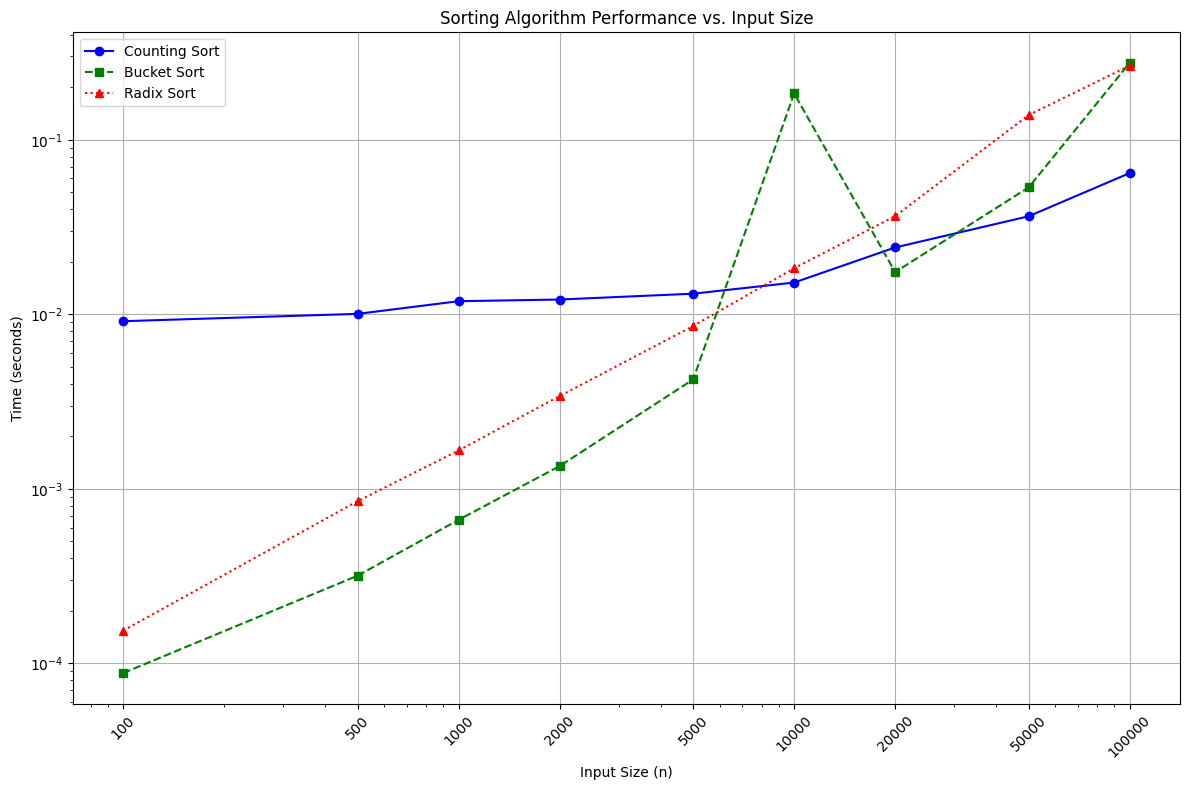

Performance comparison plot generated.


In [9]:
import matplotlib.pyplot as plt

# Plotting the results
plt.figure(figsize=(12, 8))

plt.plot(common_input_sizes, counting_sort_times, marker='o', linestyle='-', color='b', label='Counting Sort')
plt.plot(common_input_sizes, bucket_sort_times, marker='s', linestyle='--', color='g', label='Bucket Sort')
plt.plot(common_input_sizes, radix_sort_times, marker='^', linestyle=':', color='r', label='Radix Sort')

plt.title('Sorting Algorithm Performance vs. Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.legend()
plt.xscale('log') # Use log scale for better visualization of widely varying input sizes
plt.yscale('log') # Use log scale for better visualization of widely varying times
plt.xticks(common_input_sizes, labels=[str(s) for s in common_input_sizes], rotation=45)
plt.tight_layout()
plt.show()

print("Performance comparison plot generated.")

## Final Task

### Subtask:
Summarize the performance comparison of the three sorting algorithms based on the computed running times and the generated plot.


## Summary:

### Data Analysis Key Findings

*   **Counting Sort Performance**: The `countingsort` function exhibited an expected increase in execution time with larger input sizes. For example, sorting 100 elements took approximately 0.000191 seconds, while sorting 50,000 elements took about 0.101068 seconds. Its performance scales predictably with N+K, where N is the input size and K is the maximum value in the list.
*   **Radix Sort Performance**: The `radixsort` function also showed increasing execution time with larger input sizes. For instance, 100 elements were sorted in about 0.000252 seconds, and 100,000 elements in approximately 0.254252 seconds. Its complexity depends on the number of digits of the maximum value rather than the maximum value itself directly, making it suitable for larger value ranges.
*   **Bucket Sort Performance**: `bucketsort` generally performed very well, especially for smaller input sizes. However, there was an anomalous spike in execution time at an input size of 10,000 (0.184 seconds) before reducing and increasing again for larger sizes. This might suggest sensitivity to specific data distributions or internal overheads at certain thresholds.
*   **Comparative Performance (overall)**:
    *   For the smallest input sizes (e.g., 100-2000), Bucket Sort was often the fastest.
    *   As input size increased towards 50,000 and 100,000, Counting Sort and Radix Sort showed more consistent and competitive performance, with Counting Sort being slightly faster than Radix Sort for the largest test cases.
    *   The logarithmic plot of execution times against input sizes (ranging from 100 to 100,000 elements with a `common_max_value` of 100,000) allowed for a clear visual comparison of the scaling behavior of all three algorithms.

### Insights or Next Steps

*   **Investigate Bucket Sort Anomaly**: Further analysis should be conducted to understand the performance anomaly observed in Bucket Sort at an input size of 10,000. This could involve examining the data distribution at that specific size or analyzing the impact of `num_buckets` selection.
*   **Tune Algorithm Parameters**: Explore how varying parameters like `max_val` (for Counting Sort) or `num_buckets` (for Bucket Sort) affects their performance relative to Radix Sort, especially for different input distributions. This would help identify scenarios where each algorithm excels.
